This python notebook includes Summary Statistics along with feature distribution of our cleaned data histogram and then I perform K-means clustering and Hierarchial Clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({'figure.dpi':120})

df = pd.read_csv("MergedData_model.csv")
print("Original shape:", df.shape)
df.head()


Original shape: (121, 8)


,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,1,0.50
1,10,579.0,229.0,40.0,0.0,0.0,1,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0,0.75


In [3]:
df_rows = df.copy()

# Assmnt values standardized (6/10 or 'baseline','endposttr','pstwash')
print("Assmnt unique:", df['Assmnt'].unique())

# compute baseline and last post value and change
if 'Participant' in df.columns:
    pivot = df.pivot_table(index=['Participant','ID'], 
                           columns='Assmnt',
                           values=['Avg_Daily_Sed_Week_Min','Avg_Daily_Light_Week_Min',
                                   'Avg_Daily_Mod_Week_Min','Avg_Daily_Vig_Week_Min',
                                   'Avg_Daily_Very_Vig_Week_Min','Baseline_RRVscore'],
                           aggfunc='first')
    # flatten columns
    pivot.columns = ['{}_{}'.format(var, tp) for var, tp in pivot.columns]
    pivot = pivot.reset_index()
    print("Participant-level pivot shape:", pivot.shape)


Assmnt unique: [ 6 10]


In [4]:
# Select features for clustering >>
dfc = df_rows.copy()

features = [
    "Avg_Daily_Sed_Week_Min",
    "Avg_Daily_Light_Week_Min",
    "Avg_Daily_Mod_Week_Min",
    "Avg_Daily_Vig_Week_Min",
    "Avg_Daily_Very_Vig_Week_Min",
    "Baseline_RRVscore"
]

features = [f for f in features if f in dfc.columns]
print("Using features:", features)

X = dfc[features].copy()
print("Before numeric conversion dtypes:\n", X.dtypes)

for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors='coerce')
print("After numeric conversion missing per column:\n", X.isna().sum())


Using features: ['Avg_Daily_Sed_Week_Min', 'Avg_Daily_Light_Week_Min', 'Avg_Daily_Mod_Week_Min', 'Avg_Daily_Vig_Week_Min', 'Avg_Daily_Very_Vig_Week_Min', 'Baseline_RRVscore']
Before numeric conversion dtypes:
 Avg_Daily_Sed_Week_Min         float64
Avg_Daily_Light_Week_Min       float64
Avg_Daily_Mod_Week_Min         float64
Avg_Daily_Vig_Week_Min         float64
Avg_Daily_Very_Vig_Week_Min    float64
Baseline_RRVscore              float64
dtype: object
After numeric conversion missing per column:
 Avg_Daily_Sed_Week_Min         0
Avg_Daily_Light_Week_Min       0
Avg_Daily_Mod_Week_Min         0
Avg_Daily_Vig_Week_Min         0
Avg_Daily_Very_Vig_Week_Min    0
Baseline_RRVscore              0
dtype: int64


Dropped 0 rows missing key features. Remaining: 121


,count,mean,std,min,25%,50%,75%,max
Avg_Daily_Sed_Week_Min,121.0,674.900826,343.238314,170.0,418.0,514.000000,1038.0,1434.0
Avg_Daily_Light_Week_Min,121.0,212.570248,79.509834,6.0,156.0,208.000000,274.0,426.0
Avg_Daily_Mod_Week_Min,121.0,21.305785,13.186384,0.0,10.0,19.000000,29.0,60.0
Avg_Daily_Vig_Week_Min,121.0,0.752066,1.392127,0.0,0.0,0.000000,1.0,7.0
Avg_Daily_Very_Vig_Week_Min,121.0,0.123967,0.736775,0.0,0.0,0.000000,0.0,7.0
Baseline_RRVscore,121.0,0.656546,0.318875,0.0,0.5,0.666667,1.0,1.0


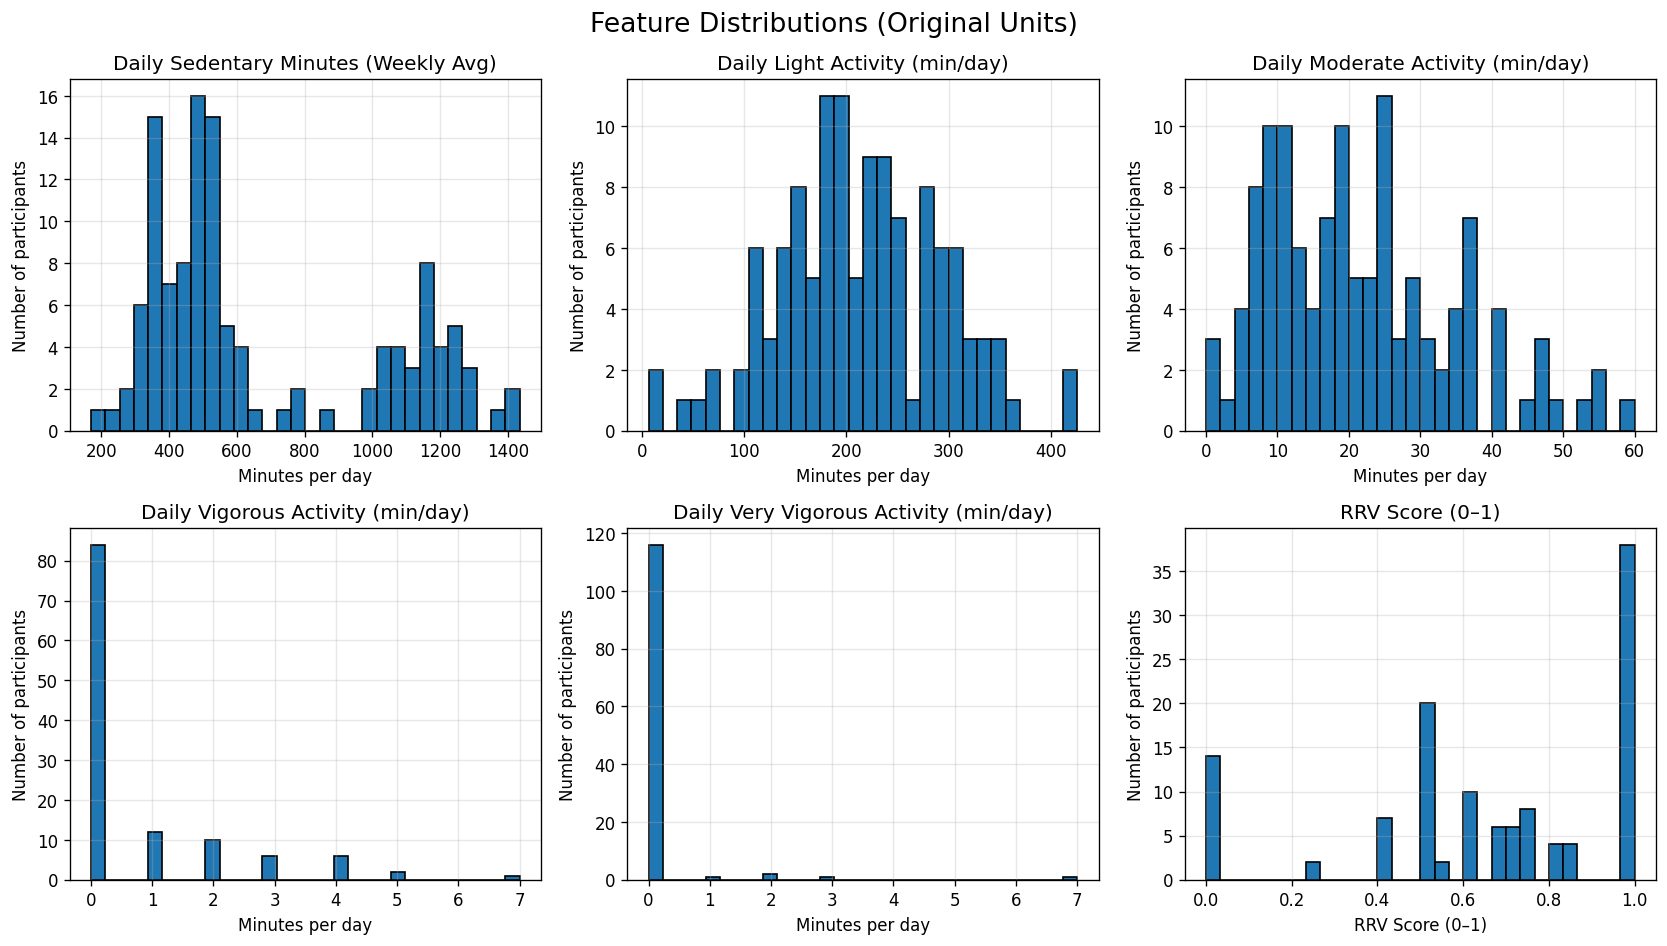

After capping 1st/99th percentiles:


,count,mean,std,min,25%,50%,75%,max
Avg_Daily_Sed_Week_Min,121.0,675.294215,341.319014,258.2,418.0,514.000000,1038.0,1389.6
Avg_Daily_Light_Week_Min,121.0,212.456198,78.344667,21.4,156.0,208.000000,274.0,403.2
Avg_Daily_Mod_Week_Min,121.0,21.269421,13.049616,1.0,10.0,19.000000,29.0,54.8
Avg_Daily_Vig_Week_Min,121.0,0.735537,1.327709,0.0,0.0,0.000000,1.0,5.0
Avg_Daily_Very_Vig_Week_Min,121.0,0.087603,0.444891,0.0,0.0,0.000000,0.0,2.8
Baseline_RRVscore,121.0,0.656546,0.318875,0.0,0.5,0.666667,1.0,1.0


In [5]:
# Handle missing and outliers
rows_before = X.shape[0]
X = X.dropna(axis=0, subset=features)
rows_after = X.shape[0]
print(f"Dropped {rows_before-rows_after} rows missing key features. Remaining: {rows_after}")

pretty_names = {
    "Avg_Daily_Sed_Week_Min": "Daily Sedentary Minutes (Weekly Avg)",
    "Avg_Daily_Light_Week_Min": "Daily Light Activity (min/day)",
    "Avg_Daily_Mod_Week_Min": "Daily Moderate Activity (min/day)",
    "Avg_Daily_Vig_Week_Min": "Daily Vigorous Activity (min/day)",
    "Avg_Daily_Very_Vig_Week_Min": "Daily Very Vigorous Activity (min/day)",
    "Baseline_RRVscore": "RRV Score (0–1)"
}

# Inspect distributions and outliers
display(X.describe().T)

# Histogram for activity and rrv scores for all particpants
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    ax = axes[i]
    ax.hist(X[col], bins=30, edgecolor="black")
    
    ax.set_title(pretty_names.get(col, col), fontsize=12)
    
    if col == "Baseline_RRVscore":
        ax.set_xlabel("RRV Score (0–1)", fontsize=10)
    else:
        ax.set_xlabel("Minutes per day", fontsize=10)
    
    ax.set_ylabel("Number of participants", fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("Feature Distributions (Original Units)", fontsize=16)
plt.tight_layout()
plt.show()


def cap_outliers(df_in, cols, lower_pct=0.01, upper_pct=0.99):
    df = df_in.copy()
    for c in cols:
        lo = df[c].quantile(lower_pct)
        hi = df[c].quantile(upper_pct)
        df[c] = df[c].clip(lo, hi)
    return df

X_capped = cap_outliers(X, X.columns, lower_pct=0.01, upper_pct=0.99)
print("After capping 1st/99th percentiles:")
display(X_capped.describe().T)


In [6]:
# Transform & scale
# Build three scaled versions and compare clustering results:
scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'power': make_pipeline(PowerTransformer(method='yeo-johnson'), StandardScaler())
}

scaled_datasets = {}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(X_capped)
    scaled_datasets[name] = scaled
    print(f"{name} scaled: mean {np.mean(scaled,axis=0).round(3)}, std {np.std(scaled,axis=0).round(3)}")


standard scaled: mean [ 0.  0. -0. -0.  0.  0.], std [1. 1. 1. 1. 1. 1.]
robust scaled: mean [ 0.26   0.038  0.119  0.736  0.088 -0.02 ], std [0.548 0.661 0.684 1.322 0.443 0.635]
power scaled: mean [ 0.  0. -0. -0.  0.  0.], std [1. 1. 1. 1. 1. 1.]


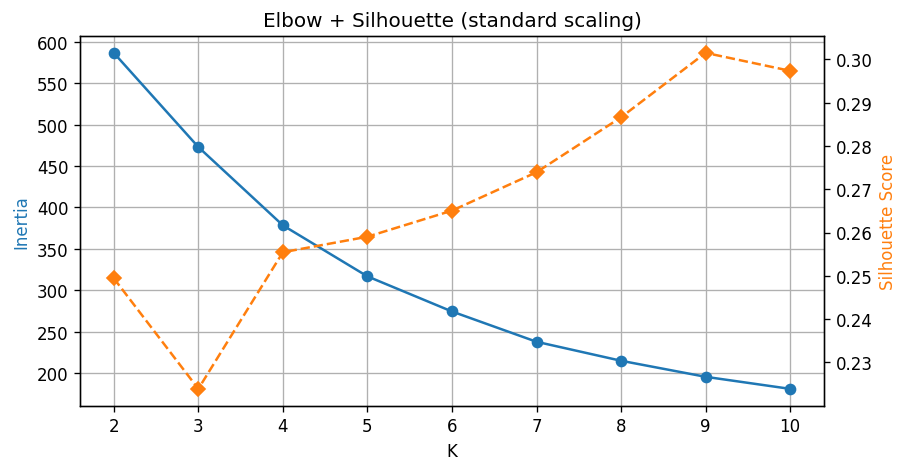

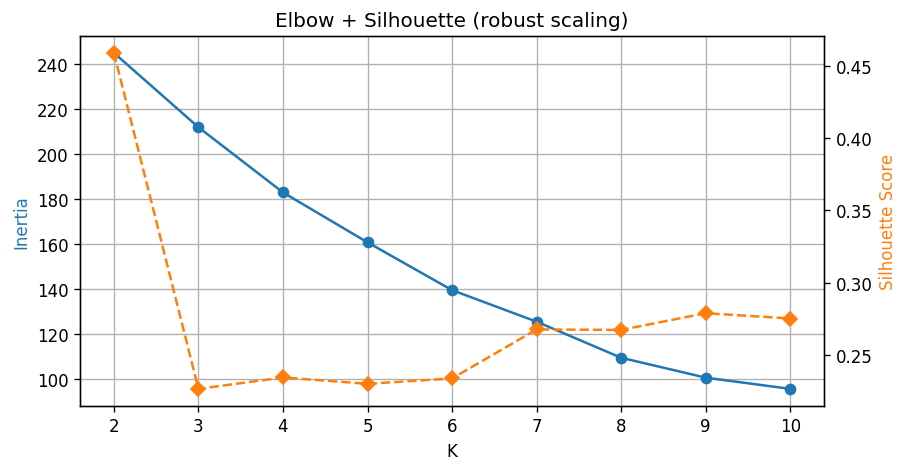

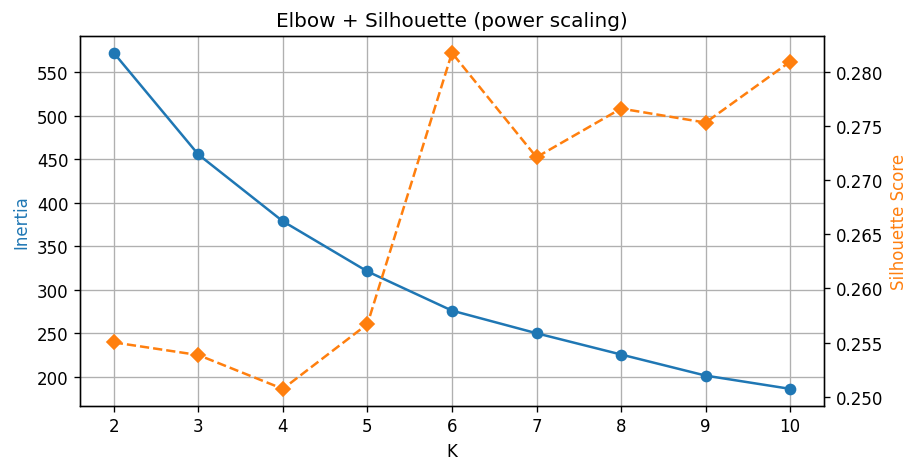

In [7]:
# How to choose K — elbow + silhouette
from sklearn.metrics import silhouette_score

def evaluate_k(X_scaled, kmin=2, kmax=10, random_state=42):
    inertias=[]
    sil_scores=[]
    Ks = list(range(kmin, kmax+1))
    for k in Ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        sil = silhouette_score(X_scaled, labels) if k>1 else np.nan
        sil_scores.append(sil)
    return Ks, inertias, sil_scores

# Evaluate for each scaler option and plot
for name, Xs in scaled_datasets.items():
    Ks, inertias, sil_scores = evaluate_k(Xs, kmin=2, kmax=10)
    
    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.plot(Ks, inertias, marker='o', label='Inertia', color='C0')
    ax1.set_xlabel("K")
    ax1.set_ylabel("Inertia", color='C0')
    
    ax2 = ax1.twinx()
    ax2.plot(Ks, sil_scores, marker='D', linestyle='--', color='C1', label='Silhouette')
    ax2.set_ylabel("Silhouette Score", color='C1')
    
    plt.title(f"Elbow + Silhouette ({name} scaling)")
    ax1.grid(True)
    plt.show()


In [8]:
# Pick K using silhouette + elbow result and compute final clustering
best_scaler_name = 'power'
k_opt = 4

X_final_scaled = scaled_datasets[best_scaler_name]
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final_scaled)
dfc = dfc.loc[X_capped.index].copy()   # align rows: X_capped index kept
dfc['Cluster'] = labels

centers_scaled = kmeans.cluster_centers_

# Convert back to original units (inverse transform)
centers_original = scalers[best_scaler_name].inverse_transform(centers_scaled)

# Create a readable dataframe
centroid_df = pd.DataFrame(centers_original, columns=features)
centroid_df['Cluster'] = range(k_opt)

print("\nCluster centroids in ORIGINAL units:")
print(centroid_df)

print("Cluster sizes:")
print(dfc['Cluster'].value_counts())

# Save clusters
dfc.to_csv("MergedData_clusters_improved.csv", index=False)
print("Saved MergedData_clusters_improved.csv")



Cluster centroids in ORIGINAL units:
   Avg_Daily_Sed_Week_Min  Avg_Daily_Light_Week_Min  Avg_Daily_Mod_Week_Min  \
0              528.776235                224.475464               27.803264   
1             1101.990218                160.804732               12.496205   
2              537.475344                206.927423               28.578478   
3              383.635385                253.972186                8.630755   

   Avg_Daily_Vig_Week_Min  Avg_Daily_Very_Vig_Week_Min  Baseline_RRVscore  \
0                1.776550                     0.006895           0.694078   
1                0.012931                     0.000000           0.628177   
2                0.000000                     0.000000           0.793176   
3                0.000000                     0.000000           0.674583   

   Cluster  
0        0  
1        1  
2        2  
3        3  
Cluster sizes:
Cluster
0    36
2    30
1    28
3    27
Name: count, dtype: int64
Saved MergedData_clusters_improved

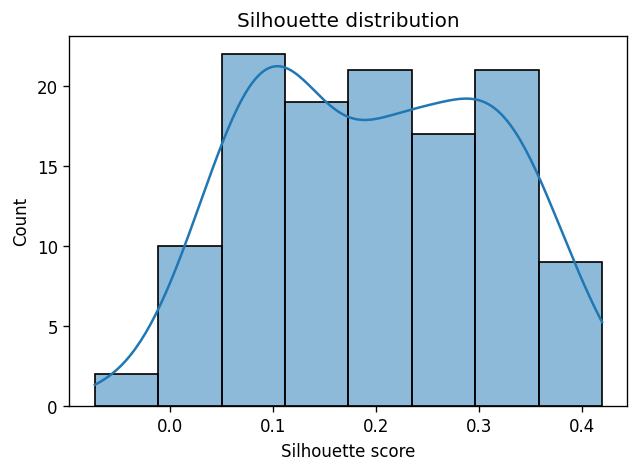

In [55]:
from sklearn.metrics import silhouette_samples

def silhouette_plot(X_scaled, labels):
    s = silhouette_samples(X_scaled, labels)
    plt.figure(figsize=(6,4))
    sns.histplot(s, kde=True)
    plt.title("Silhouette distribution")
    plt.xlabel("Silhouette score")
    plt.show()

silhouette_plot(X_final_scaled, labels)

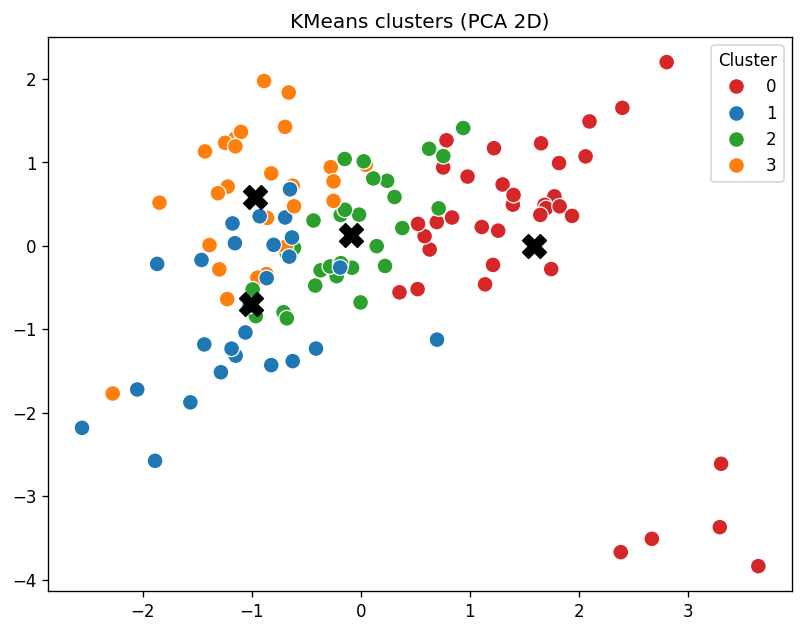

In [9]:
# << Cell 8: Visualize via PCA & profile clusters >>
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final_scaled)

palette = {0:"tab:red", 1:"tab:blue", 2:"tab:green", 3:"tab:orange"}

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], 
                hue=dfc['Cluster'],
                palette=palette,
                s=90)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:,0], centers_pca[:,1], 
            c='black', s=200, marker='X')
plt.title("KMeans clusters (PCA 2D)")
plt.show()




In [10]:
# Also show counts by RRV_label or Assmnt
print("\nCounts by cluster and RRV_label:")
print(pd.crosstab(dfc['Cluster'], dfc['RRV_label']))
print("\nCounts by cluster and Assmnt:")
print(pd.crosstab(dfc['Cluster'], dfc['Assmnt']))


Counts by cluster and RRV_label:
RRV_label   0   1
Cluster          
0          21  15
1          17  11
2          17  13
3          22   5

Counts by cluster and Assmnt:
Assmnt   6   10
Cluster        
0        17  19
1        13  15
2        15  15
3        13  14


Hierarchial Clustering

In [11]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

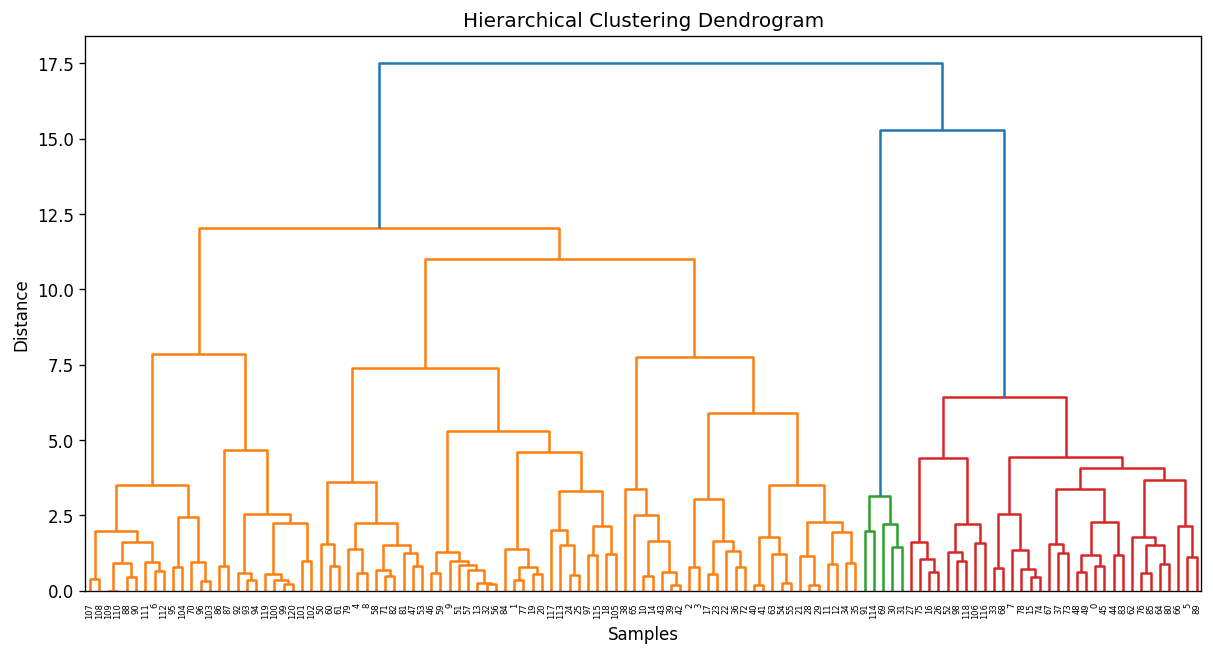

In [12]:
Z = linkage(X_final_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [13]:
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hier_labels = hc.fit_predict(X_final_scaled)

dfc["Cluster_HC"] = hier_labels
dfc["Cluster_HC"].value_counts()

Cluster_HC
0    59
3    32
1    25
2     5
Name: count, dtype: int64

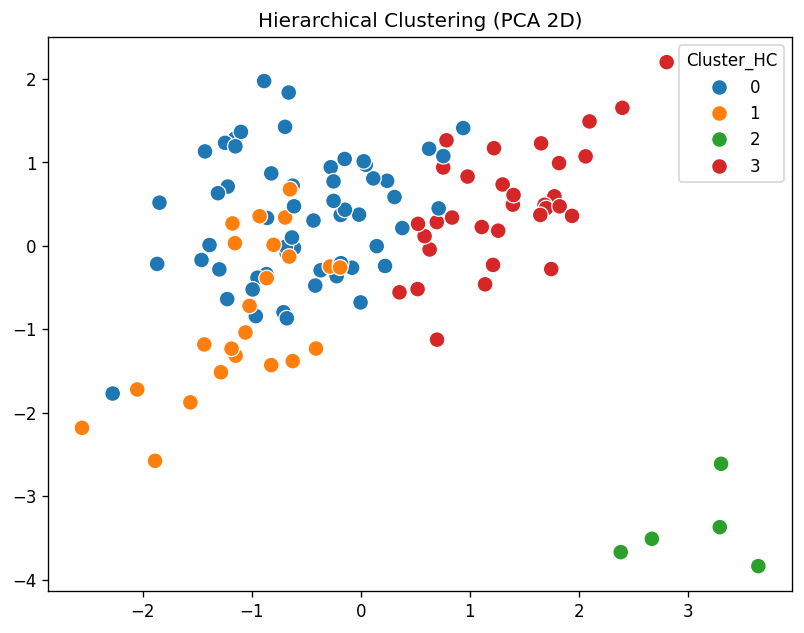

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], 
                hue=dfc['Cluster_HC'],
                palette='tab10', s=90)
plt.title("Hierarchical Clustering (PCA 2D)")
plt.show()


In [15]:
dfc.groupby("Cluster_HC").mean()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore,Cluster
Cluster_HC,,,,,,,,,
0,7.966102,498.661017,227.338983,19.389831,0.00000,0.0,0.305085,0.675592,2.40678
1,8.240000,1179.400000,162.920000,14.280000,0.00000,0.0,0.440000,0.599333,1.04000
2,7.600000,782.800000,162.800000,24.400000,3.60000,3.0,0.000000,0.870000,0.00000
3,8.250000,588.843750,231.906250,29.843750,2.28125,0.0,0.468750,0.632775,0.03125
